# SUPPORT  VECTOR REGRESSION

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
data = pd.read_csv('Position_Salaries.csv')
x=data.iloc[:,1:-1].values
y=data.iloc[:,-1].values

# Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
x=sc_x.fit_transform(x)
y=sc_y.fit_transform(y.reshape(-1,1))
x,y

(array([[-1.5132889 ],
        [-1.18431305],
        [-0.8553372 ],
        [-0.52636136],
        [-0.19738551],
        [ 0.13159034],
        [ 0.46056619],
        [ 0.78954203],
        [ 1.11851788],
        [ 1.77646958]]),
 array([[-0.69024159],
        [-0.67415204],
        [-0.64197294],
        [-0.57761475],
        [-0.48107747],
        [-0.35236109],
        [-0.19146561],
        [ 0.13032533],
        [ 0.77390723],
        [ 2.70465293]]))

# Traning the SVR Model

In [24]:
from sklearn.svm import SVR
regressor=SVR(kernel='rbf')
regressor.fit(x,y)

C:\Users\adity\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [25]:
y_pred=regressor.predict(x)
y_pred=sc_y.inverse_transform(y_pred.reshape(-1,1))
y_pred


array([[ 76136.0635085 ],
       [ 69080.52317304],
       [ 85770.65302749],
       [111032.82240274],
       [135404.51644105],
       [166120.91970403],
       [225482.84954935],
       [331102.59829872],
       [468880.66380877],
       [637857.01913316]])

# Visualising the SVR result

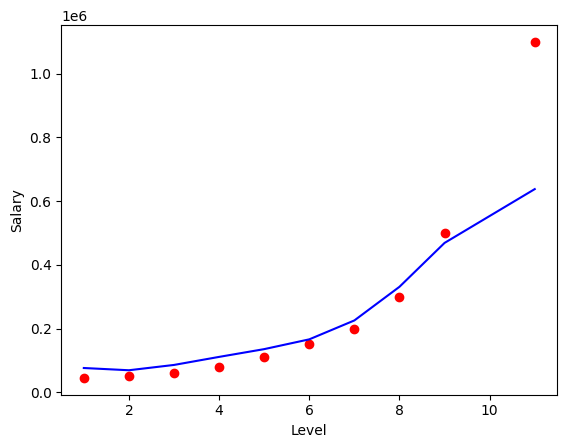

In [26]:
plt.plot(sc_x.inverse_transform(x),y_pred,color='blue')
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y),color='red')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

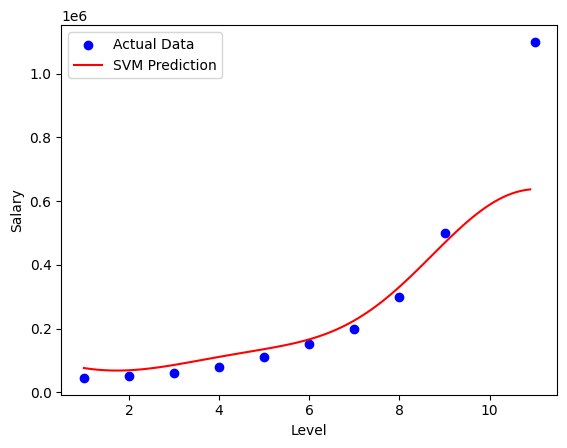

In [28]:

X_original = sc_x.inverse_transform(x)
y_original = sc_y.inverse_transform(y.reshape(-1, 1))


X_grid = np.arange(
    X_original.min(),
    X_original.max(),
    0.1
).reshape(-1, 1)

y_grid_scaled = regressor.predict(sc_x.transform(X_grid))

y_grid = sc_y.inverse_transform(y_grid_scaled.reshape(-1, 1))

plt.scatter(X_original, y_original, color='blue', label='Actual Data')
plt.plot(X_grid, y_grid, color='red', label='SVM Prediction')

plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()
